In [19]:
# ============================================================
# PART 1: Understanding the Dataset
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('Titanic-Dataset.csv')

print("=" * 50)
print("SHAPE OF DATASET")
print("=" * 50)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("COLUMN NAMES & DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
print(df.head())

print("\n" + "=" * 50)
print("TARGET VARIABLE: 'Survived'")
print("=" * 50)
print(df['Survived'].value_counts())
print(f"\n0 = Did Not Survive | 1 = Survived")

print("\n" + "=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
print(df.describe())

SHAPE OF DATASET
Rows: 891, Columns: 12

COLUMN NAMES & DATA TYPES
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

FIRST 5 ROWS
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                          

MISSING VALUES
          Missing Count  Missing %
Age                 177  19.865320
Cabin               687  77.104377
Embarked              2   0.224467


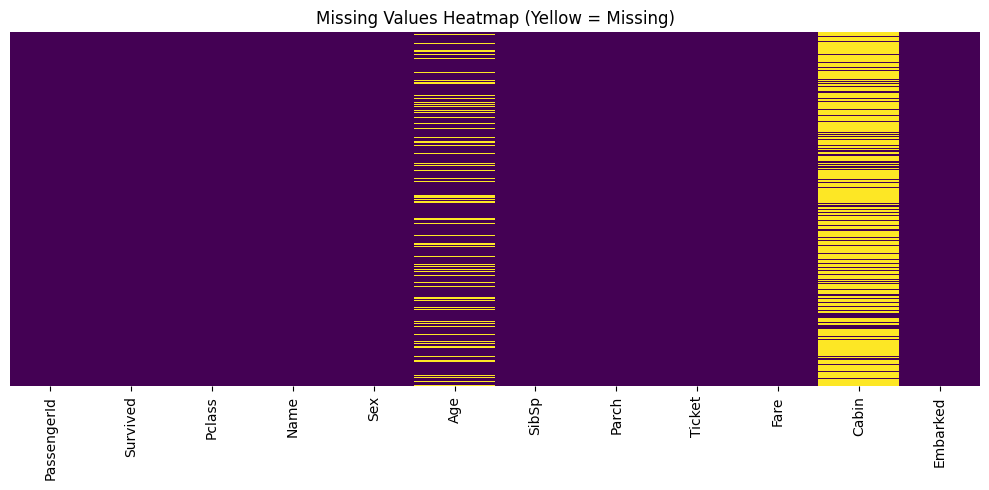


After handling missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [20]:
# ============================================================
# PART 2: Checking and Handling Missing Values
# ============================================================

print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap (Yellow = Missing)")
plt.tight_layout()
plt.savefig('missing_heatmap.png')
plt.show()

# Handle missing values:
# Age (177 missing ~19.9%) → fill with median (robust to outliers)
df['Age'].fillna(df['Age'].median(), inplace=True)

# Cabin (687 missing ~77%) → too many missing, drop the column
df.drop(columns=['Cabin'], inplace=True)

# Embarked (2 missing ~0.2%) → fill with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

print("\nAfter handling missing values:")
print(df.isnull().sum())

In [21]:
# ============================================================
# PART 3: Removing Duplicate Records
# ============================================================

print("=" * 50)
print("DUPLICATE RECORDS CHECK")
print("=" * 50)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found. Dataset is clean.")

DUPLICATE RECORDS CHECK
Total duplicate rows: 0
No duplicates found. Dataset is clean.


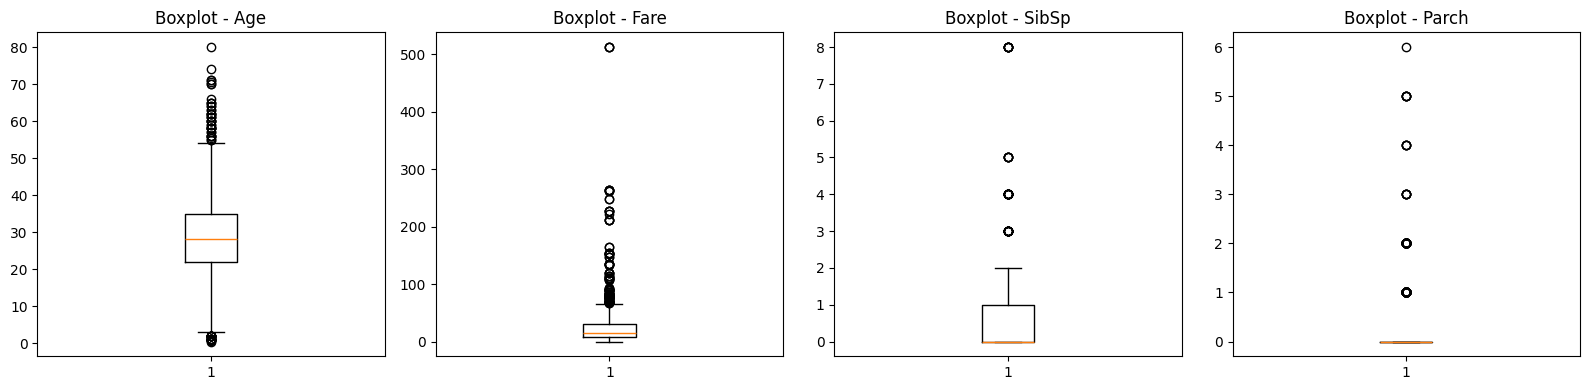

Outlier Treatment (IQR Capping):
Age: 66 outliers capped | Range: [2.50, 54.50]
Fare: 116 outliers capped | Range: [-26.72, 65.63]


In [22]:
# ============================================================
# PART 4: Detecting and Handling Outliers
# ============================================================

numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

# Visualize outliers with boxplots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'Boxplot - {col}')
plt.tight_layout()
plt.savefig('outliers_boxplot.png')
plt.show()

# Handle outliers using IQR method (cap/clip outliers)
def cap_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"{col}: {before} outliers capped | Range: [{lower:.2f}, {upper:.2f}]")
    return df

print("Outlier Treatment (IQR Capping):")
for col in ['Age', 'Fare']:
    df = cap_outliers_iqr(df, col)

In [23]:
# ============================================================
# PART 5: Handling Incorrect Data Types
# ============================================================

print("=" * 50)
print("DATA TYPES BEFORE FIX")
print("=" * 50)
print(df.dtypes)

# Pclass is ordinal (1, 2, 3) — store as category
df['Pclass'] = df['Pclass'].astype('category')

# Survived is binary target — keep as int (0/1) for modeling
df['Survived'] = df['Survived'].astype(int)

print("\nData Types AFTER Fix:")
print(df.dtypes)

DATA TYPES BEFORE FIX
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

Data Types AFTER Fix:
PassengerId       int64
Survived          int64
Pclass         category
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
dtype: object


In [24]:
# ============================================================
# PART 6: Handling Categorical Variables
# ============================================================

# Sex → Binary → Label Encoding (0 = female, 1 = male)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])  # female=0, male=1
print("Sex encoded:", df['Sex'].unique())

# Embarked → Nominal (S, C, Q) → One-Hot Encoding
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
print("Columns after One-Hot Encoding:", df.columns.tolist())

# Pclass → Already ordinal integers (1, 2, 3) → convert back to int for models
df['Pclass'] = df['Pclass'].astype(int)

print("\nSample after encoding:")
print(df.head())

Sex encoded: [1 0]
Columns after One-Hot Encoding: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked_Q', 'Embarked_S']

Sample after encoding:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    1  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    0  38.0      1      0   
2                             Heikkinen, Miss. Laina    0  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    0  35.0      1      0   
4                           Allen, Mr. William Henry    1  35.0      0      0   

             Ticket     Fare  Embarked_Q  Embarked_S  
0         A/5 21171   7.2500       False  

In [25]:
# ============================================================
# PART 7: Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

# Scale continuous numerical features
scale_cols = ['Age', 'Fare']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("After StandardScaler (Age, Fare):")
print(df[scale_cols].describe().round(3))

After StandardScaler (Age, Fare):
           Age     Fare
count  891.000  891.000
mean     0.000    0.000
std      1.001    1.001
min     -2.200   -1.175
25%     -0.583   -0.788
50%     -0.086   -0.469
75%      0.494    0.340
max      2.110    2.032


In [26]:
# ============================================================
# PART 8: Removing Irrelevant or Redundant Features
# ============================================================

print("Columns before removal:", df.columns.tolist())

# Drop irrelevant features:
# PassengerId → just an index, no predictive value
# Name → free text, too unique to encode meaningfully
# Ticket → alphanumeric, high cardinality, no direct signal
df.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

print("Columns after removal:", df.columns.tolist())
print("Final Shape:", df.shape)

Columns before removal: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked_Q', 'Embarked_S']
Columns after removal: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
Final Shape: (891, 9)


Skewness of numerical features (before treatment):
  Pclass: -0.629
  Sex: -0.618
  Age: 0.164
  SibSp: 3.689
  Parch: 2.744
  Fare: 1.080


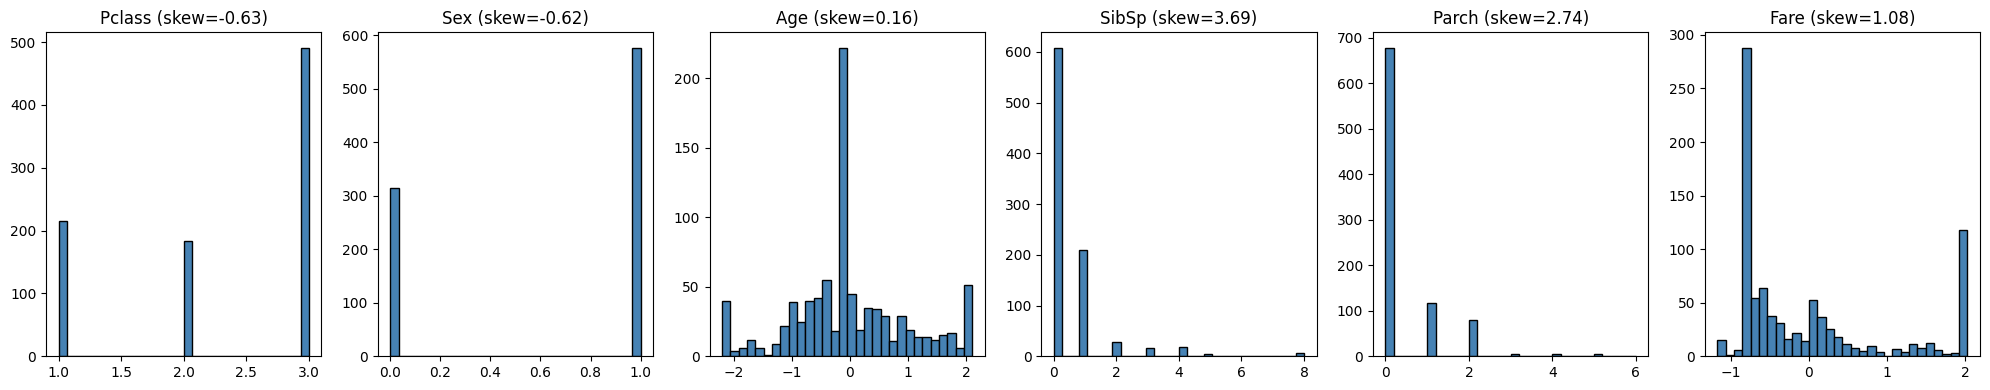


✅ PREPROCESSING COMPLETE
Final cleaned dataset shape: (891, 9)
Final columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
   Survived  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked_Q  \
0         0       3    1 -0.583432      1      0 -0.820552       False   
1         1       1    0  0.742685      1      0  2.031623       False   
2         1       3    0 -0.251903      0      0 -0.787578       False   
3         1       1    0  0.494038      1      0  1.419297       False   
4         0       3    1  0.494038      0      0 -0.781471       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


In [28]:
# ============================================================
# PART 9: Handling Skewness
# ============================================================
from scipy.stats import skew

print("Skewness of numerical features (before treatment):")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('Survived')  # Exclude target

for col in num_cols:
    sk = skew(df[col])
    print(f"  {col}: {sk:.3f}")

# Note: After StandardScaler, Age and Fare are already transformed.
# SibSp and Parch are discrete counts — skewed but acceptable for tree models.
# If using linear models, apply log1p on original skewed columns before scaling.

# Visualize skewness
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col} (skew={skew(df[col]):.2f})')
plt.tight_layout()
plt.savefig('skewness_plots.png')
plt.show()

print("\n✅ PREPROCESSING COMPLETE")
print("Final cleaned dataset shape:", df.shape)
print("Final columns:", df.columns.tolist())
print(df.head())

Train size: (712, 8), Test size: (179, 8)

  MODEL: Logistic Regression
  Accuracy  : 0.7933
  Precision : 0.7667
  Recall    : 0.6667
  F1 Score  : 0.7132
  ROC-AUC   : 0.8403

  Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.81      0.87      0.84       110
       Survived       0.77      0.67      0.71        69

       accuracy                           0.79       179
      macro avg       0.79      0.77      0.78       179
   weighted avg       0.79      0.79      0.79       179



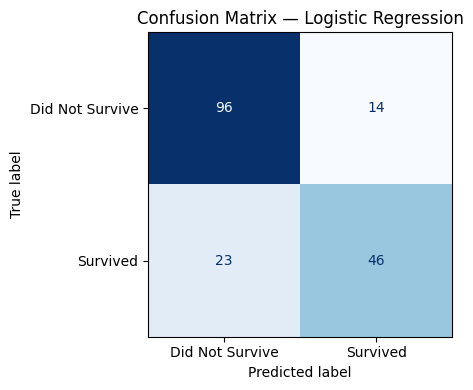


  MODEL: Random Forest
  Accuracy  : 0.7821
  Precision : 0.7419
  Recall    : 0.6667
  F1 Score  : 0.7023
  ROC-AUC   : 0.8207

  Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.80      0.85      0.83       110
       Survived       0.74      0.67      0.70        69

       accuracy                           0.78       179
      macro avg       0.77      0.76      0.77       179
   weighted avg       0.78      0.78      0.78       179



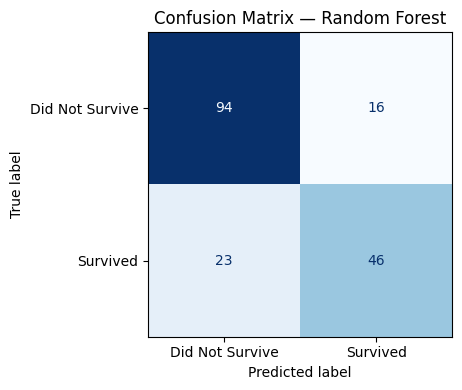


  MODEL: SVM (RBF Kernel)
  Accuracy  : 0.8268
  Precision : 0.8276
  Recall    : 0.6957
  F1 Score  : 0.7559
  ROC-AUC   : 0.8321

  Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.91      0.87       110
       Survived       0.83      0.70      0.76        69

       accuracy                           0.83       179
      macro avg       0.83      0.80      0.81       179
   weighted avg       0.83      0.83      0.82       179



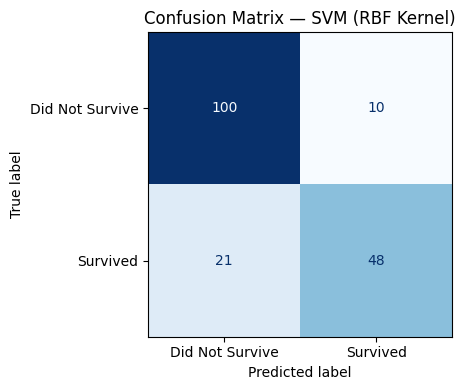


         FINAL MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7933     0.7667  0.6667    0.7132   0.8403
Random Forest          0.7821     0.7419  0.6667    0.7023   0.8207
SVM (RBF Kernel)       0.8268     0.8276  0.6957    0.7559   0.8321


In [29]:
# ============================================================
# PART 10: Model Training, Evaluation & Confusion Matrix
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, ConfusionMatrixDisplay)

# ── Prepare X, y ──
X = df.drop(columns=['Survived'])
y = df['Survived']

# ── Train-Test Split (80/20) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

# ── Define 3 Models ──
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF Kernel)":    SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  MODEL: {name}")
    print(f"{'='*55}")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    cm   = confusion_matrix(y_test, y_pred)

    results[name] = {'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1 Score': f1, 'ROC-AUC': auc}

    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")

    print("\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

    # Confusion Matrix plot
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Did Not Survive', 'Survived'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_")}.png')
    plt.show()

# ── Final Comparison Table ──
print("\n" + "="*60)
print("         FINAL MODEL COMPARISON TABLE")
print("="*60)
results_df = pd.DataFrame(results).T.round(4)
print(results_df)